# Data understanding

Saving student-mat.csv to student-mat (1).csv
=== Informasi Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-n

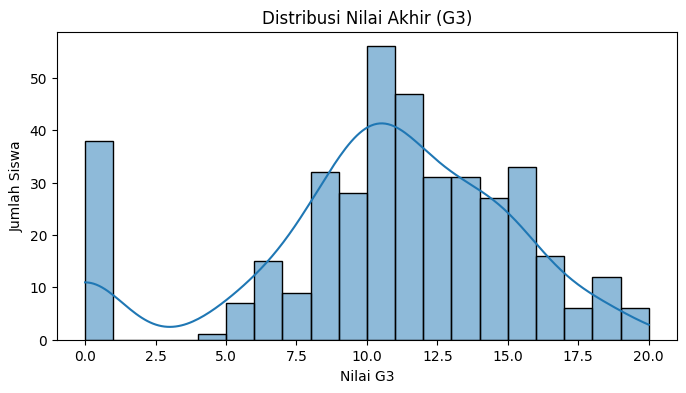

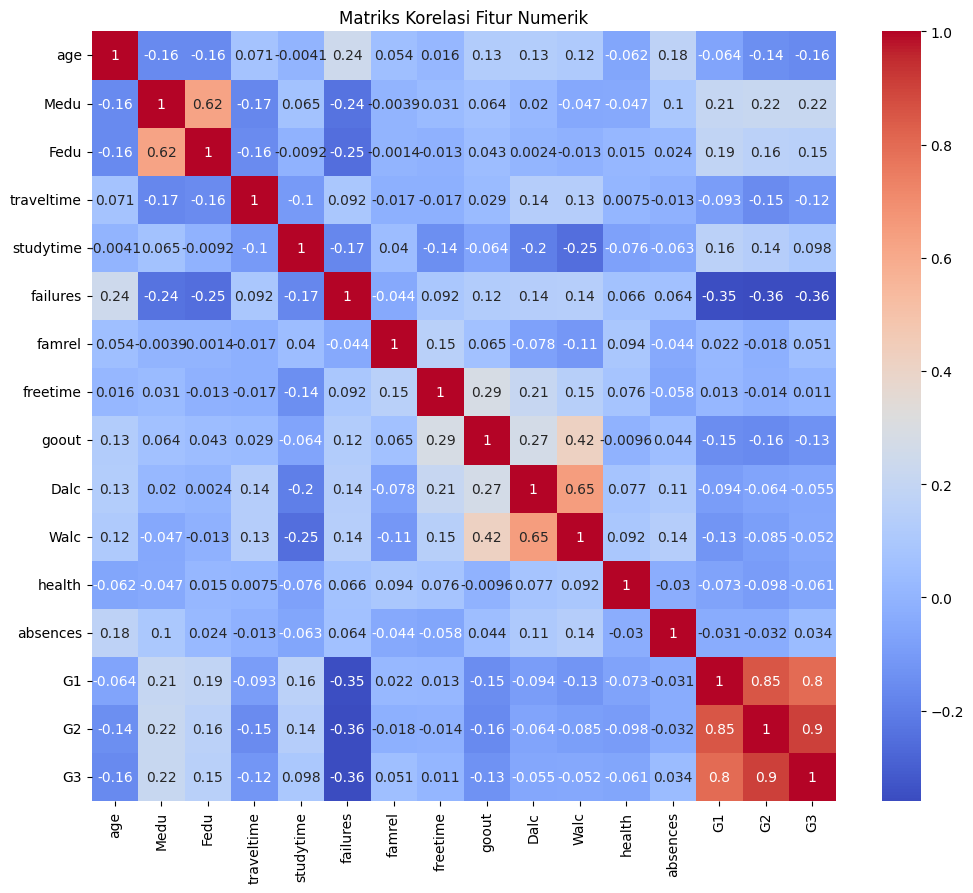

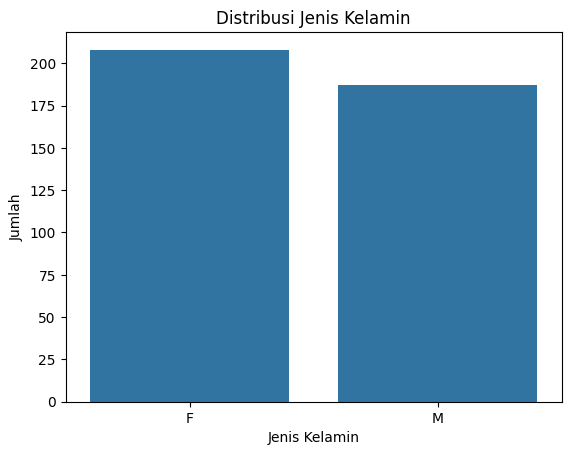

In [4]:
# 1. Upload File
from google.colab import files
uploaded = files.upload()

# 2. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# 3. Load Dataset dengan delimiter ';'
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';')

# 4. Eksplorasi Struktur Data
print("=== Informasi Data ===")
print(df.info())
print("\n=== 5 Data Teratas ===")
print(df.head())

# 5. Statistik Deskriptif
print("\n=== Statistik Deskriptif ===")
print(df.describe(include='all'))

# 6. Cek Nilai Kosong
print("\n=== Jumlah Nilai Kosong ===")
print(df.isnull().sum())

# 7. Distribusi Nilai Akhir (G3)
if 'G3' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df['G3'], bins=20, kde=True)
    plt.title('Distribusi Nilai Akhir (G3)')
    plt.xlabel('Nilai G3')
    plt.ylabel('Jumlah Siswa')
    plt.show()

# 8. Korelasi Antar Fitur Numerik
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

# 9. Distribusi Kolom Kategorik (contoh: 'sex')
if 'sex' in df.columns:
    sns.countplot(data=df, x='sex')
    plt.title('Distribusi Jenis Kelamin')
    plt.xlabel('Jenis Kelamin')
    plt.ylabel('Jumlah')
    plt.show()


# Preprocessing 

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Cek ulang nilai kosong
print("Nilai kosong per kolom:")
print(df.isnull().sum())

# 2. Pisahkan fitur kategorikal & numerikal
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nFitur kategorikal:")
print(categorical_cols.tolist())
print("\nFitur numerik:")
print(numerical_cols.tolist())

# 3. Encoding variabel kategorikal (menggunakan one-hot encoding)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Normalisasi fitur numerik
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# 5. Tentukan fitur (X) dan target (y)
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

# 6. Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nUkuran Data Train: {X_train.shape}")
print(f"Ukuran Data Test : {X_test.shape}")


Nilai kosong per kolom:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Fitur kategorikal:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Fitur numerik:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Ukuran Data Train: (316, 41)
Ukuran Data Test : (79, 41)


# Modelling

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fungsi bantu evaluasi model
def evaluate_model(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"MAE : {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE : {mean_squared_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R²   : {r2_score(y_true, y_pred):.2f}")
    print()

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model("Linear Regression", y_test, y_pred_lr)

# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model("Random Forest", y_test, y_pred_rf)

# 3. KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
evaluate_model("KNN Regressor", y_test, y_pred_knn)


=== Linear Regression ===
MAE : 0.36
MSE : 0.27
RMSE: 0.52
R²   : 0.72

=== Random Forest ===
MAE : 0.26
MSE : 0.18
RMSE: 0.42
R²   : 0.82

=== KNN Regressor ===
MAE : 0.50
MSE : 0.49
RMSE: 0.70
R²   : 0.50



# Evaluasi

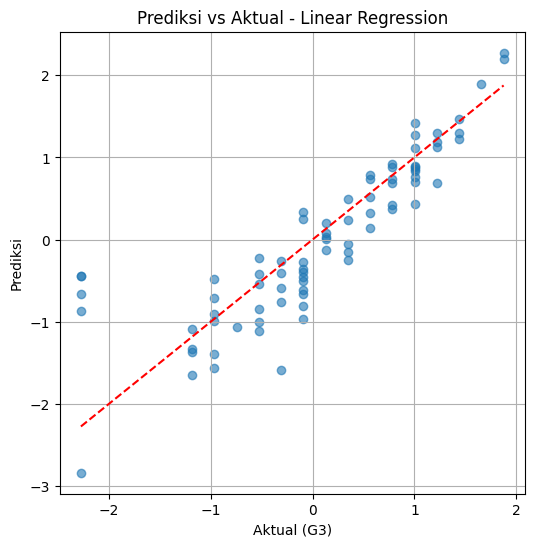

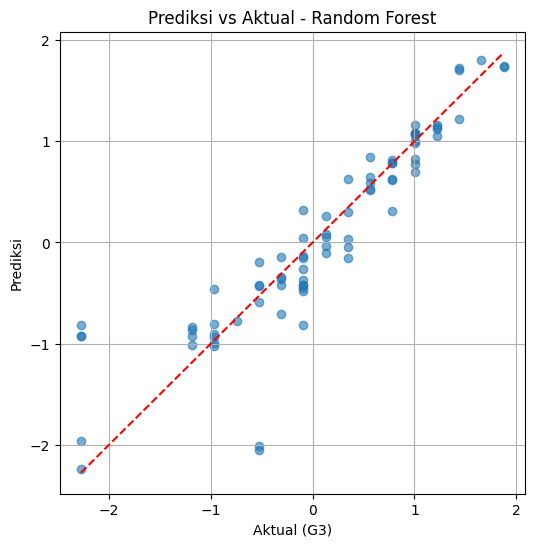

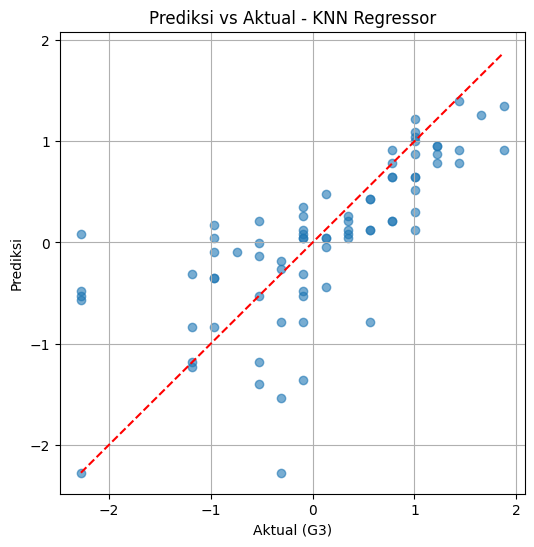

In [7]:
import matplotlib.pyplot as plt

# 1. Visualisasi Prediksi vs Aktual
def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel("Aktual (G3)")
    plt.ylabel("Prediksi")
    plt.title(f"Prediksi vs Aktual - {title}")
    plt.grid(True)
    plt.show()

# Visualisasi untuk ketiga model
plot_pred_vs_actual(y_test, y_pred_lr, "Linear Regression")
plot_pred_vs_actual(y_test, y_pred_rf, "Random Forest")
plot_pred_vs_actual(y_test, y_pred_knn, "KNN Regressor")


In [ ]:
!pip install gradio

In [ ]:
import joblib

# Simpan model terbaik dan scaler
joblib.dump(rf, 'model_random_forest.pkl')
joblib.dump(scaler, 'scaler.pkl')


In [ ]:
import gradio as gr
import numpy as np

# Load model dan scaler
model = joblib.load('model_random_forest.pkl')
scaler = joblib.load('scaler.pkl')

# Nama-nama fitur yang dipakai model (samakan dengan X_train.columns)
feature_names = X_train.columns.tolist()

# Fungsi prediksi
def predict_g3(*input_features):
    # Ubah input ke array lalu scale
    input_array = np.array(input_features).reshape(1, -1)
    input_scaled = scaler.transform(input_array)
    
    # Prediksi G3
    prediction = model.predict(input_scaled)[0]
    return f"Prediksi Nilai Akhir (G3): {prediction:.2f}"

# Buat interface input
inputs = [gr.Number(label=col) for col in feature_names]

# Gradio Interface
interface = gr.Interface(
    fn=predict_g3,
    inputs=inputs,
    outputs=gr.Textbox(label="Hasil Prediksi"),
    title="Prediksi Nilai Akhir Siswa",
    description="Masukkan data siswa dan dapatkan prediksi nilai akhirnya (G3)"
)

# Jalankan
interface.launch(share=True)  # share=True agar dapat URL publik
